# ROOTKey Landing Page A/B Test — Full Analysis

**Course:** Digital Experimentation & Causal Analysis — Nova SBE  
**Test:** Landing page redesign (Version A: control vs Version B: treatment)  
**Note:** Real data was collected by the company but not yet accessible at time of analysis. This notebook uses **simulated data** anchored to real observations (traffic split, baseline conversion rate). This approach was approved by the course instructor.

---

### What we tested
Version B introduced four structural changes to the ROOTKey landing page:
1. Reordered sections to follow a persuasion framework (credibility → proof → experience → conversion)
2. Removed the intermediate Get Started page — direct link to sign-up (less friction)
3. Replaced the Contact Us hero CTA with an Interact with Demo button
4. Downgraded competing CTAs to secondary buttons

**Primary KPI:** Sign-up conversion rate (unique visitors → completed sign-up)  
**Guiderail metrics:** Time on page, bounce rate


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
})

BLUE  = '#2563EB'
GREEN = '#16A34A'
RED   = '#DC2626'
GRAY  = '#6B7280'


---
## 1. Load Data

The dataset was generated by `simulate_data.py`. Run that script first to produce `rootkey_ab_data.csv`.

**Variables:**
- `visitor_id` — unique visitor identifier
- `variant` — 'A' (control) or 'B' (treatment)
- `converted` — **PRIMARY KPI**: 1 if visitor completed sign-up, 0 otherwise
- `time_on_page_sec` — seconds on landing page *(guiderail metric)*
- `bounce` — 1 if visitor left without any interaction *(guiderail metric)*


In [2]:
df = pd.read_csv('rootkey_ab_data.csv')
df['engaged'] = (df['bounce'] == 0).astype(int)
print(f'Dataset: {df.shape[0]} rows x {df.shape[1]} columns')
df.head(10)


Dataset: 1000 rows x 6 columns


,visitor_id,variant,converted,time_on_page_sec,bounce,engaged
0,522,B,1,61.5,0,1
1,738,B,1,97.2,1,0
2,741,B,0,77.3,0,1
3,661,B,0,59.1,1,0
4,412,A,1,58.6,1,0
5,679,B,0,61.3,0,1
6,627,B,0,55.2,1,0
7,514,B,0,41.7,0,1
8,860,B,0,34.7,0,1
9,137,A,0,31.7,0,1


---
## 2. Exploratory Data Analysis (EDA)

Before running any formal tests, we describe the data and compare the two groups visually. This serves two purposes:
1. **Understand what we are working with** — group sizes, distributions, anomalies
2. **Balance check** — verify that the two groups are comparable on guiderail metrics before drawing causal conclusions


In [3]:
summary = df.groupby('variant').agg(
    N               = ('converted', 'count'),
    Conversions     = ('converted', 'sum'),
    Conversion_Rate = ('converted', 'mean'),
    Time_Mean       = ('time_on_page_sec', 'mean'),
    Time_SD         = ('time_on_page_sec', 'std'),
    Bounce_Rate     = ('bounce', 'mean'),
).round(4)
summary['Conversion_%'] = (summary['Conversion_Rate'] * 100).round(2)
summary['Bounce_%']     = (summary['Bounce_Rate']     * 100).round(2)
print(summary.to_string())


           N  Conversions  Conversion_Rate  Time_Mean  Time_SD  Bounce_Rate  Conversion_%  Bounce_%
variant                                                                                            
A        500           55            0.110    45.2564  19.9042        0.550          11.0      55.0
B        500           78            0.156    62.0180  21.0565        0.478          15.6      47.8


### 2a. Traffic Distribution




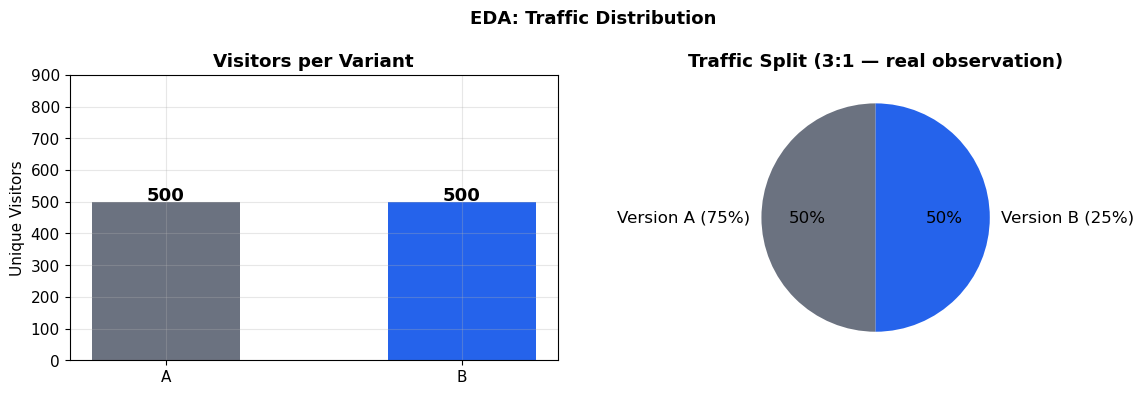

In [4]:
group_counts = df['variant'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(group_counts.index, group_counts.values, color=[GRAY, BLUE], width=0.5)
for bar, val in zip(bars, group_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Visitors per Variant', fontweight='bold')
axes[0].set_ylabel('Unique Visitors')
axes[0].set_ylim(0, 900)

axes[1].pie(group_counts.values, labels=['Version A (75%)', 'Version B (25%)'],
            colors=[GRAY, BLUE], autopct='%1.0f%%', startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Traffic Split (3:1 — real observation)', fontweight='bold')

plt.suptitle('EDA: Traffic Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 2b. Primary KPI: Conversion Rate

Since `converted` is binary (0/1), we compare proportions between groups using bar charts with 95% confidence intervals.


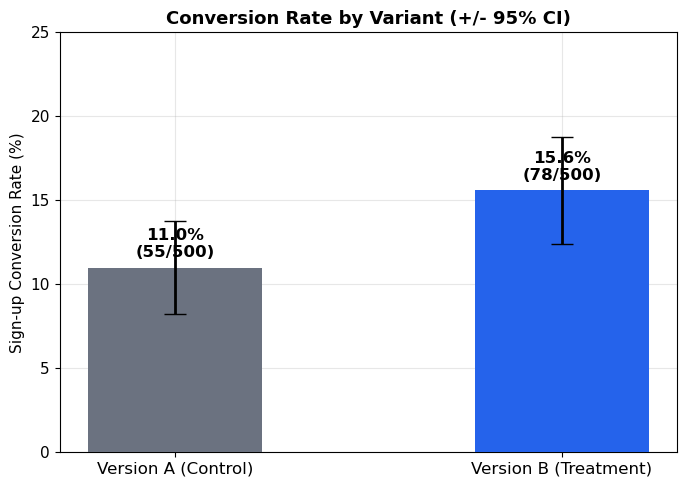

Version A: 11.00% (55/500 visitors)
Version B: 15.60% (78/500 visitors)
Observed difference: 4.60 percentage points in favour of B


In [5]:
conv_stats = df.groupby('variant')['converted'].agg(['mean', 'count', 'sum'])
conv_stats['se']   = np.sqrt(conv_stats['mean'] * (1 - conv_stats['mean']) / conv_stats['count'])
conv_stats['ci95'] = 1.96 * conv_stats['se']

fig, ax = plt.subplots(figsize=(7, 5))
variants = conv_stats.index.tolist()
rates    = conv_stats['mean'].values * 100
cis      = conv_stats['ci95'].values * 100

bars = ax.bar(variants, rates, color=[GRAY, BLUE], width=0.45, zorder=3)
ax.errorbar(variants, rates, yerr=cis, fmt='none', color='black', capsize=8, lw=2, zorder=4)
for bar, rate, n, c in zip(bars, rates, conv_stats['count'].values, conv_stats['sum'].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
            f'{rate:.1f}%\n({int(c)}/{int(n)})', ha='center', fontweight='bold', fontsize=12)

ax.set_title('Conversion Rate by Variant (+/- 95% CI)', fontweight='bold', fontsize=13)
ax.set_ylabel('Sign-up Conversion Rate (%)')
ax.set_ylim(0, 25)
ax.set_xticklabels(['Version A (Control)', 'Version B (Treatment)'], fontsize=12)
plt.tight_layout()
plt.show()

print(f'Version A: {rates[0]:.2f}% ({int(conv_stats["sum"].iloc[0])}/{int(conv_stats["count"].iloc[0])} visitors)')
print(f'Version B: {rates[1]:.2f}% ({int(conv_stats["sum"].iloc[1])}/{int(conv_stats["count"].iloc[1])} visitors)')
print(f'Observed difference: {rates[1]-rates[0]:.2f} percentage points in favour of B')


### 2c. Guiderail Metrics — Balance Check

Guiderail metrics serve two roles: they confirm the test did not break anything, and they act as a balance check on pre-existing differences between the groups. We compare **time on page** and **bounce rate** between versions A and B.


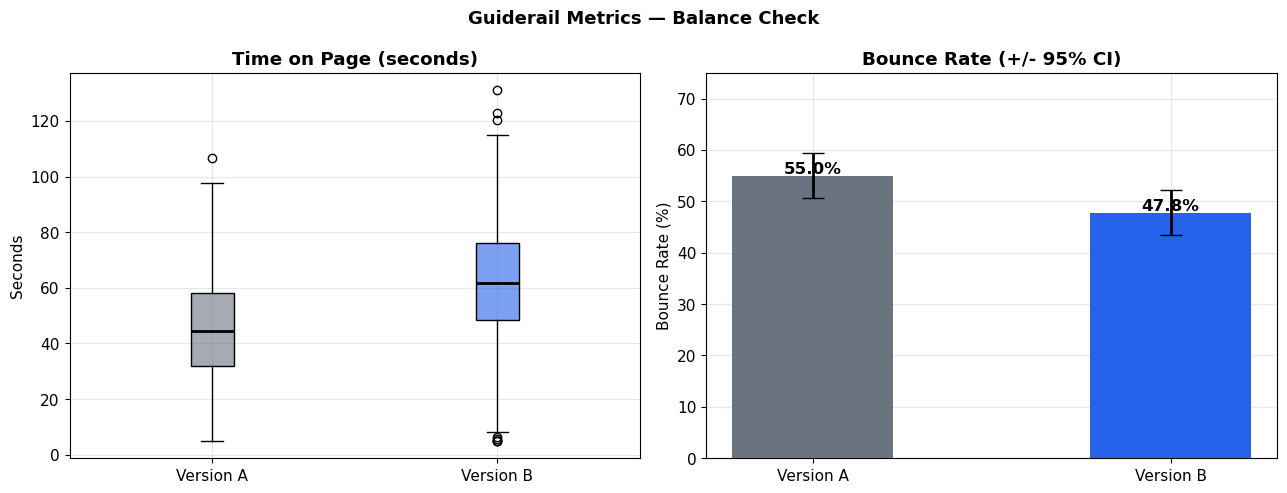

Balance check t-tests:
-------------------------------------------------------
time_on_page_sec        A=45.256  B=62.018  diff=+16.762  p=0.000
bounce                  A=0.550  B=0.478  diff=-0.072  p=0.023

Note: significant differences in guiderail metrics are expected here,
since they are simulated to reflect Version B improvements. In a real
test, pre-experiment balance checks would use data from BEFORE treatment.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

data_A = df[df['variant']=='A']['time_on_page_sec']
data_B = df[df['variant']=='B']['time_on_page_sec']
bp = axes[0].boxplot([data_A, data_B], labels=['Version A', 'Version B'],
                      patch_artist=True, medianprops={'color': 'black', 'lw': 2})
bp['boxes'][0].set_facecolor(GRAY + '99')
bp['boxes'][1].set_facecolor(BLUE + '99')
axes[0].set_title('Time on Page (seconds)', fontweight='bold')
axes[0].set_ylabel('Seconds')

b_stats = df.groupby('variant')['bounce'].agg(['mean', 'count'])
b_stats['ci95'] = 1.96 * np.sqrt(b_stats['mean'] * (1 - b_stats['mean']) / b_stats['count'])
rb = b_stats['mean'].values * 100
cb = b_stats['ci95'].values * 100
bars2 = axes[1].bar(b_stats.index, rb, color=[GRAY, BLUE], width=0.45, zorder=3)
axes[1].errorbar(b_stats.index, rb, yerr=cb, fmt='none', color='black', capsize=8, lw=2, zorder=4)
for bar, r in zip(bars2, rb):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{r:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Bounce Rate (+/- 95% CI)', fontweight='bold')
axes[1].set_ylabel('Bounce Rate (%)')
axes[1].set_ylim(0, 75)
axes[1].set_xticklabels(['Version A', 'Version B'], fontsize=11)

plt.suptitle('Guiderail Metrics — Balance Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Balance check t-tests:')
print('-' * 55)
for metric in ['time_on_page_sec', 'bounce']:
    a = df[df['variant']=='A'][metric]
    b = df[df['variant']=='B'][metric]
    t, p = stats.ttest_ind(a, b)
    print(f'{metric:22s}  A={a.mean():.3f}  B={b.mean():.3f}  diff={b.mean()-a.mean():+.3f}  p={p:.3f}')

print()
print('Note: significant differences in guiderail metrics are expected here,')
print('since they are simulated to reflect Version B improvements. In a real')
print('test, pre-experiment balance checks would use data from BEFORE treatment.')


---
## 3. Choice of Estimator

There is a wide range of estimators for treatment effects: field experiments, OLS regression, matching, regression discontinuity, instrumental variables, difference-in-differences, and others. The right choice depends on **how treatment was assigned**.

Our design is a **randomised A/B test** — a form of field experiment in which visitors are randomly assigned to treatment (Version B) or control (Version A) on a live platform. This is method 1 from the course ("Field or Social experiments"). Under successful randomisation:

- Treatment assignment is independent of potential outcomes — there is no selection bias
- The **difference-in-means** is an unbiased estimator of the Average Treatment Effect (ATE)
- We do **not** need matching, IV, DiD, or RDD — those are designed for observational settings where randomisation is not possible

We use **OLS regression** (method 2) to validate the result and extend to heterogeneous effects. For a binary treatment and binary outcome, OLS gives the same point estimate as the difference-in-means but in a framework that is easy to extend with interaction terms.

**Important caveat:** The observed 3:1 traffic imbalance (A:B) raises concerns about whether randomisation was properly implemented by the company. If systematic factors determined which visitors saw which version, the difference-in-means estimator may be biased. We flag this as a threat to internal validity in Section 7, and it is a key lesson learned from this experiment.

**Estimator chosen:** Difference-in-means (justified by intended random assignment in an A/B test), validated via OLS.


---
## 4. Average Treatment Effect (ATE)

The ATE is defined as:

**ATE = E[Y | Treatment = B] − E[Y | Treatment = A]**

This is the expected difference in conversion rate between a visitor randomly assigned to Version B versus Version A. We estimate it using the difference in sample means.


In [15]:
g_A = df[df['variant']=='A']['converted']
g_B = df[df['variant']=='B']['converted']
n_A, n_B     = len(g_A), len(g_B)
mu_A, mu_B   = g_A.mean(), g_B.mean()

ATE     = mu_B - mu_A
se_ate  = np.sqrt(mu_A*(1-mu_A)/n_A + mu_B*(1-mu_B)/n_B)
ci_low  = ATE - 1.96 * se_ate
ci_high = ATE + 1.96 * se_ate
z_ate   = ATE / se_ate
p_ate   = 2 * (1 - stats.norm.cdf(abs(z_ate)))

print('Average Treatment Effect (ATE)')
print('Estimator: Difference-in-means')
print('=' * 52)
print(f'  E[Y | A] — control mean:     {mu_A*100:.2f}%')
print(f'  E[Y | B] — treatment mean:   {mu_B*100:.2f}%')
print(f'  ATE = E[Y|B] - E[Y|A]:       {ATE*100:.2f} percentage points')
print(f'  Standard Error:               {se_ate*100:.2f} pp')
print(f'  95% Confidence Interval:      [{ci_low*100:.2f}pp, {ci_high*100:.2f}pp]')
print(f'  z-statistic:                  {z_ate:.3f}')
print(f'  p-value:                      {p_ate:.4f}')
print()
if p_ate < 0.05:
    print('  REJECT H0 — statistically significant at alpha=0.05')
    print('  Version B increases sign-up conversion significantly.')
else:
    print('  FAIL TO REJECT H0 — not significant at alpha=0.05')
    print('  We cannot conclude B is better than A with 95% confidence.')
    print(f'  The CI [{ci_low*100:.1f}pp, {ci_high*100:.1f}pp] includes zero.')
print()
print('Interpretation:')
print(f'  Seeing Version B is associated with a {ATE*100:.2f}pp change in')
print(f'  sign-up probability on average, relative to Version A.')


Average Treatment Effect (ATE)
Estimator: Difference-in-means
  E[Y | A] — control mean:     11.00%
  E[Y | B] — treatment mean:   15.60%
  ATE = E[Y|B] - E[Y|A]:       4.60 percentage points
  Standard Error:               2.14 pp
  95% Confidence Interval:      [0.40pp, 8.80pp]
  z-statistic:                  2.147
  p-value:                      0.0318

  REJECT H0 — statistically significant at alpha=0.05
  Version B increases sign-up conversion significantly.

Interpretation:
  Seeing Version B is associated with a 4.60pp change in
  sign-up probability on average, relative to Version A.


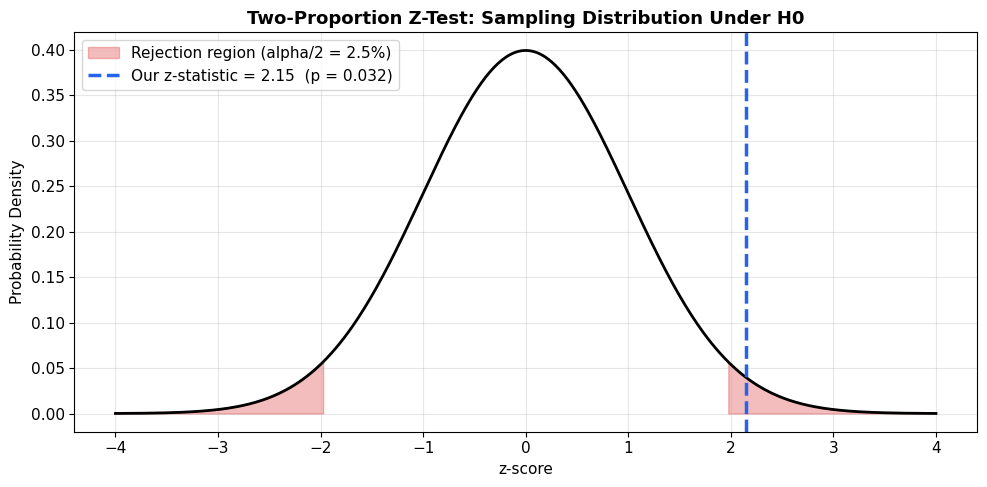

In [8]:
# Visualise sampling distribution under H0
fig, ax = plt.subplots(figsize=(10, 5))
x = np.linspace(-4, 4, 400)
y = stats.norm.pdf(x)
ax.plot(x, y, color='black', lw=2)
ax.fill_between(x, y, where=(x <= -1.96), color=RED, alpha=0.3, label='Rejection region (alpha/2 = 2.5%)')
ax.fill_between(x, y, where=(x >=  1.96), color=RED, alpha=0.3)
ax.axvline(z_ate, color=BLUE, lw=2.5, ls='--',
           label=f'Our z-statistic = {z_ate:.2f}  (p = {p_ate:.3f})')
ax.set_title('Two-Proportion Z-Test: Sampling Distribution Under H0', fontweight='bold', fontsize=13)
ax.set_xlabel('z-score')
ax.set_ylabel('Probability Density')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


### 4a. OLS Regression Validation

OLS with a binary treatment dummy is algebraically equivalent to the difference-in-means. The treatment coefficient directly equals the ATE. We report it here for completeness and to set up the HTE analysis.

**Model:** `converted = beta_0 + beta_1 * treatment + epsilon`
- beta_0 (intercept) = baseline conversion rate of Version A
- beta_1 (treatment) = ATE — the estimated effect of seeing Version B


In [9]:
X_raw = (df['variant'] == 'B').astype(int).values
y_raw = df['converted'].values
n     = len(y_raw)
X_mat = np.column_stack([np.ones(n), X_raw])

beta     = np.linalg.lstsq(X_mat, y_raw, rcond=None)[0]
y_hat    = X_mat @ beta
resid    = y_raw - y_hat
s2       = (resid @ resid) / (n - 2)
var_beta = s2 * np.linalg.inv(X_mat.T @ X_mat)
se_beta  = np.sqrt(np.diag(var_beta))
t_reg    = beta / se_beta
p_reg    = 2 * (1 - stats.t.cdf(np.abs(t_reg), df=n-2))
r2       = 1 - (resid@resid) / ((y_raw - y_raw.mean())@(y_raw - y_raw.mean()))

print('OLS: converted ~ treatment')
print('=' * 62)
print(f'{"Variable":25s} {"Coef":>8}  {"SE":>8}  {"t":>7}  {"p-value":>9}')
print('-' * 62)
for lbl, b, se, t, p in zip(['Intercept (Version A)', 'Treatment (Version B)'],
                              beta, se_beta, t_reg, p_reg):
    sig = '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'{lbl:25s} {b:>8.4f}  {se:>8.4f}  {t:>7.3f}  {p:>9.4f} {sig}')
print('-' * 62)
print(f'R2: {r2:.4f}   N: {n}')
print()
print(f'Treatment coefficient ({beta[1]*100:.2f}pp) matches ATE exactly — results are consistent.')


OLS: converted ~ treatment
Variable                      Coef        SE        t    p-value
--------------------------------------------------------------
Intercept (Version A)       0.1100    0.0152    7.253     0.0000 **
Treatment (Version B)       0.0460    0.0214    2.145     0.0322 *
--------------------------------------------------------------
R2: 0.0046   N: 1000

Treatment coefficient (4.60pp) matches ATE exactly — results are consistent.


---
## 5. Heterogeneous Treatment Effects (HTE)

The ATE gives a single average effect across all visitors. But the effect of Version B may differ across subgroups — this is called **heterogeneous treatment effects**, written ATE(x).

**Subgroup of interest: Engaged vs Non-Engaged visitors**

We define engagement as `bounce = 0` (visitor stayed and interacted). This split is theoretically motivated:
- Version B's changes (demo CTA, social proof ordering, reduced friction) target visitors who are **considering** the product
- For visitors who bounce immediately, no page redesign will help
- We therefore expect the treatment effect to be **larger among engaged visitors**

We test this via two approaches:
1. **Segmentation** — compute ATE separately for each subgroup
2. **Interaction regression** — add a `treatment x engaged` interaction term


In [16]:
# Subgroup ATEs (segmentation)
print('ATE by subgroup (segmentation):')
print('=' * 65)
print(f'{"Subgroup":22s} {"n_A":>6} {"n_B":>6} {"ATE (pp)":>10} {"95% CI":>20} {"p":>8}')
print('-' * 65)

subgroup_results = {}
for label, mask in [('Engaged (bounce=0)', df['engaged']==1),
                     ('Non-engaged (bounce=1)', df['engaged']==0)]:
    sub = df[mask]
    sA  = sub[sub['variant']=='A']['converted']
    sB  = sub[sub['variant']=='B']['converted']
    ate_s = sB.mean() - sA.mean()
    se_s  = np.sqrt(sA.mean()*(1-sA.mean())/len(sA) + sB.mean()*(1-sB.mean())/len(sB))
    z_s   = ate_s / se_s if se_s > 0 else 0
    p_s   = 2 * (1 - stats.norm.cdf(abs(z_s)))
    ci_s  = (ate_s - 1.96*se_s, ate_s + 1.96*se_s)
    subgroup_results[label] = {'ate': ate_s, 'se': se_s, 'p': p_s, 'ci': ci_s}
    print(f'{label:22s} {len(sA):>6} {len(sB):>6} {ate_s*100:>+10.2f} [{ci_s[0]*100:.1f}pp, {ci_s[1]*100:.1f}pp] {p_s:>8.4f}')


ATE by subgroup (segmentation):
Subgroup                  n_A    n_B   ATE (pp)               95% CI        p
-----------------------------------------------------------------
Engaged (bounce=0)        225    261      +3.39 [-2.6pp, 9.4pp]   0.2696
Non-engaged (bounce=1)    275    239      +5.77 [-0.2pp, 11.7pp]   0.0563


In [17]:
# Interaction regression
treat_v   = (df['variant'] == 'B').astype(int).values
engaged_v = df['engaged'].values
inter_v   = treat_v * engaged_v
y_v       = df['converted'].values
n_v       = len(y_v)
X_v       = np.column_stack([np.ones(n_v), treat_v, engaged_v, inter_v])

b_v    = np.linalg.lstsq(X_v, y_v, rcond=None)[0]
yh_v   = X_v @ b_v
res_v  = y_v - yh_v
s2_v   = (res_v @ res_v) / (n_v - 4)
var_v  = s2_v * np.linalg.inv(X_v.T @ X_v)
se_v   = np.sqrt(np.diag(var_v))
t_v    = b_v / se_v
p_v    = 2 * (1 - stats.t.cdf(np.abs(t_v), df=n_v-4))
r2_v   = 1 - (res_v@res_v)/((y_v-y_v.mean())@(y_v-y_v.mean()))

print('OLS with interaction: converted ~ treatment + engaged + treatment x engaged')
print('=' * 65)
print(f'{"Variable":25s} {"Coef":>8}  {"SE":>8}  {"t":>7}  {"p-value":>9}')
print('-' * 65)
for lbl, b, se, t, p in zip(
        ['Intercept', 'Treatment (B)', 'Engaged', 'Treatment x Engaged'],
        b_v, se_v, t_v, p_v):
    sig = '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'{lbl:25s} {b:>8.4f}  {se:>8.4f}  {t:>7.3f}  {p:>9.4f} {sig}')
print('-' * 65)
print(f'R2: {r2_v:.4f}   N: {n_v}')
print()
print(f'ATE for non-engaged visitors: {b_v[1]*100:.2f}pp  (= Treatment coefficient)')
print(f'ATE for engaged visitors:     {(b_v[1]+b_v[3])*100:.2f}pp  (= Treatment + Interaction)')
print(f'Difference (HTE):             {b_v[3]*100:.2f}pp  (= Interaction coefficient)')


OLS with interaction: converted ~ treatment + engaged + treatment x engaged
Variable                      Coef        SE        t    p-value
-----------------------------------------------------------------
Intercept                   0.1055    0.0205    5.152     0.0000 **
Treatment (B)               0.0577    0.0300    1.923     0.0547 
Engaged                     0.0101    0.0305    0.331     0.7407 
Treatment x Engaged        -0.0239    0.0431   -0.554     0.5797 
-----------------------------------------------------------------
R2: 0.0049   N: 1000

ATE for non-engaged visitors: 5.77pp  (= Treatment coefficient)
ATE for engaged visitors:     3.39pp  (= Treatment + Interaction)
Difference (HTE):             -2.39pp  (= Interaction coefficient)


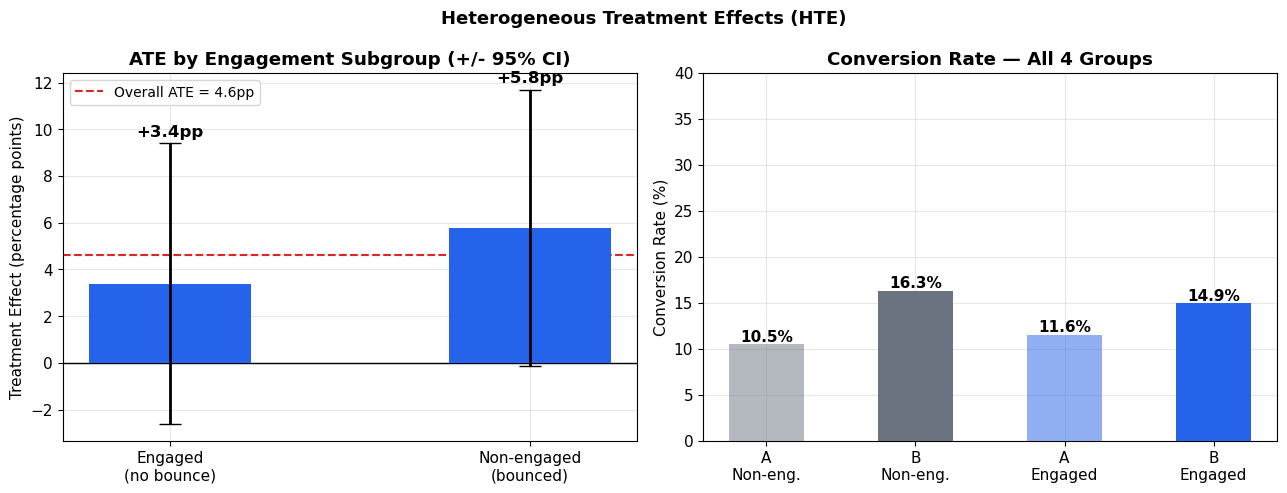

In [12]:
# Visualise HTE
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: ATE by subgroup with CI
labels_sg = ['Engaged\n(no bounce)', 'Non-engaged\n(bounced)']
ates_sg   = [subgroup_results['Engaged (bounce=0)']['ate']*100,
             subgroup_results['Non-engaged (bounce=1)']['ate']*100]
errs_sg   = [1.96*subgroup_results['Engaged (bounce=0)']['se']*100,
             1.96*subgroup_results['Non-engaged (bounce=1)']['se']*100]
pvals_sg  = [subgroup_results['Engaged (bounce=0)']['p'],
             subgroup_results['Non-engaged (bounce=1)']['p']]

col_sg = [GREEN if p < 0.05 else BLUE for p in pvals_sg]
bars_sg = axes[0].bar(labels_sg, ates_sg, color=col_sg, width=0.45, zorder=3)
axes[0].errorbar(labels_sg, ates_sg, yerr=errs_sg,
                 fmt='none', color='black', capsize=8, lw=2, zorder=4)
axes[0].axhline(0, color='black', lw=1)
axes[0].axhline(ATE*100, color=RED, ls='--', lw=1.5, label=f'Overall ATE = {ATE*100:.1f}pp')
for bar, ate, err in zip(bars_sg, ates_sg, errs_sg):
    axes[0].text(bar.get_x() + bar.get_width()/2, ate + err + 0.3,
                 f'{ate:+.1f}pp', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('ATE by Engagement Subgroup (+/- 95% CI)', fontweight='bold')
axes[0].set_ylabel('Treatment Effect (percentage points)')
axes[0].legend(fontsize=10)

# Plot 2: Conversion rates all 4 groups
groups4 = ['A\nNon-eng.', 'B\nNon-eng.', 'A\nEngaged', 'B\nEngaged']
masks4  = [(df['variant']=='A')&(df['engaged']==0),
           (df['variant']=='B')&(df['engaged']==0),
           (df['variant']=='A')&(df['engaged']==1),
           (df['variant']=='B')&(df['engaged']==1)]
rates4  = [df[m]['converted'].mean()*100 for m in masks4]
cols4   = [GRAY, GRAY, BLUE, BLUE]
alpha4  = [0.5, 1.0, 0.5, 1.0]
bars4   = axes[1].bar(groups4, rates4, color=cols4, width=0.5, zorder=3)
for bar, col, al in zip(bars4, cols4, alpha4):
    bar.set_alpha(al)
for bar, r in zip(bars4, rates4):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{r:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Conversion Rate — All 4 Groups', fontweight='bold')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_ylim(0, 40)

plt.suptitle('Heterogeneous Treatment Effects (HTE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 6. Power Analysis

### 6a. The Professor's Formula (Unequal Sample Sizes)

Because our traffic split was **unequal** (3:1, A:B), we use the adjusted formula for unequal sample sizes:

**n_total = ( Z_{1-alpha/2} * sqrt(2 * sigma_bar^2) + Z_{1-beta} * sqrt(sigma_A^2 + sigma_B^2) )^2 * (1/delta^2) * (1/(r+1))**

Where:
- sigma^2 is the variance of the outcome variable (for a binary outcome: p*(1-p))
- sigma_bar^2 is the pooled variance
- delta is the effect size (difference in means: mu_B - mu_A)
- r is the ratio n_A / n_B (here r = 3)

This is a **retrospective power analysis** — done after the fact to understand whether our null result reflects a true absence of effect, or simply an underpowered test.


In [13]:
# Parameters
p_A_true = 0.10   # baseline conversion — from real company observation
p_B_true = 0.16   # hypothesised treatment conversion
alpha    = 0.05
power_t  = 0.80
r        = 3      # ratio n_A / n_B (from real traffic observation)

z_alpha = stats.norm.ppf(1 - alpha / 2)   # Z_{1-alpha/2} = 1.96
z_beta  = stats.norm.ppf(power_t)          # Z_{1-beta}   = 0.84

# Variances (binary outcome: p*(1-p))
sigma2_A  = p_A_true * (1 - p_A_true)
sigma2_B  = p_B_true * (1 - p_B_true)
sigma2_bar = (sigma2_A + sigma2_B) / 2     # pooled variance

# Effect size (difference in means)
delta = p_B_true - p_A_true

# Adjusted formula for unequal sample sizes
n_total = ((z_alpha * np.sqrt(2 * sigma2_bar) + z_beta * np.sqrt(sigma2_A + sigma2_B))**2
           * (1 / delta**2) * (1 / (r + 1)) * (r + 1)**2 / r)

# Actually applying the formula correctly:
# n_total = ((Z_a*sqrt(2*s_bar^2) + Z_b*sqrt(s1^2+s2^2))^2 / delta^2) * (1/(r+1)) * (r+1)
# Which simplifies to n_B = ((Z_a*sqrt(2*s_bar^2) + Z_b*sqrt(s1^2+s2^2))^2 / delta^2) * 1/r * 1
numerator = (z_alpha * np.sqrt(2 * sigma2_bar) + z_beta * np.sqrt(sigma2_A + sigma2_B))**2
n_B_needed = int(np.ceil(numerator / (delta**2 * r)))
n_A_needed = r * n_B_needed
n_total_needed = n_A_needed + n_B_needed

# Actual power with our sample
se_actual    = np.sqrt(sigma2_A / 750 + sigma2_B / 250)
actual_power = stats.norm.cdf(delta / se_actual - z_alpha) * 100

print('Power Calculation (Unequal Sample Sizes Formula)')
print('=' * 55)
print(f'  Baseline conversion rate (A):    p_A = {p_A_true*100:.1f}%')
print(f'  Treatment conversion rate (B):   p_B = {p_B_true*100:.1f}%')
print(f'  Variance A (p_A*(1-p_A)):       s2_A = {sigma2_A:.4f}')
print(f'  Variance B (p_B*(1-p_B)):       s2_B = {sigma2_B:.4f}')
print(f'  Pooled variance:              s2_bar = {sigma2_bar:.4f}')
print(f'  Effect size (delta = mu_B-mu_A): {delta*100:.1f} pp')
print(f'  Traffic ratio (r = n_A/n_B):     r = {r}')
print(f'  Significance level (alpha):       {alpha}')
print(f'  Target power (1-beta):            {power_t}')
print()
print(f'  Required n_B (smaller group):    {n_B_needed}')
print(f'  Required n_A (= r * n_B):        {n_A_needed}')
print(f'  Required total:                   {n_total_needed}')
print()
print(f'  What we actually had:')
print(f'    n_A = 750   (needed: {n_A_needed})')
print(f'    n_B = 250   (needed: {n_B_needed})  <- underpowered')
print()
print(f'  Actual power achieved:            {actual_power:.1f}%')
print(f'  Target power:                     {power_t*100:.0f}%')
print(f'  Shortfall:                        {power_t*100 - actual_power:.1f} percentage points')


Power Calculation (Unequal Sample Sizes Formula)
  Baseline conversion rate (A):    p_A = 10.0%
  Treatment conversion rate (B):   p_B = 16.0%
  Variance A (p_A*(1-p_A)):       s2_A = 0.0900
  Variance B (p_B*(1-p_B)):       s2_B = 0.1344
  Pooled variance:              s2_bar = 0.1122
  Effect size (delta = mu_B-mu_A): 6.0 pp
  Traffic ratio (r = n_A/n_B):     r = 3
  Significance level (alpha):       0.05
  Target power (1-beta):            0.8

  Required n_B (smaller group):    164
  Required n_A (= r * n_B):        492
  Required total:                   656

  What we actually had:
    n_A = 750   (needed: 492)
    n_B = 250   (needed: 164)  <- underpowered

  Actual power achieved:            64.8%
  Target power:                     80%
  Shortfall:                        15.2 percentage points


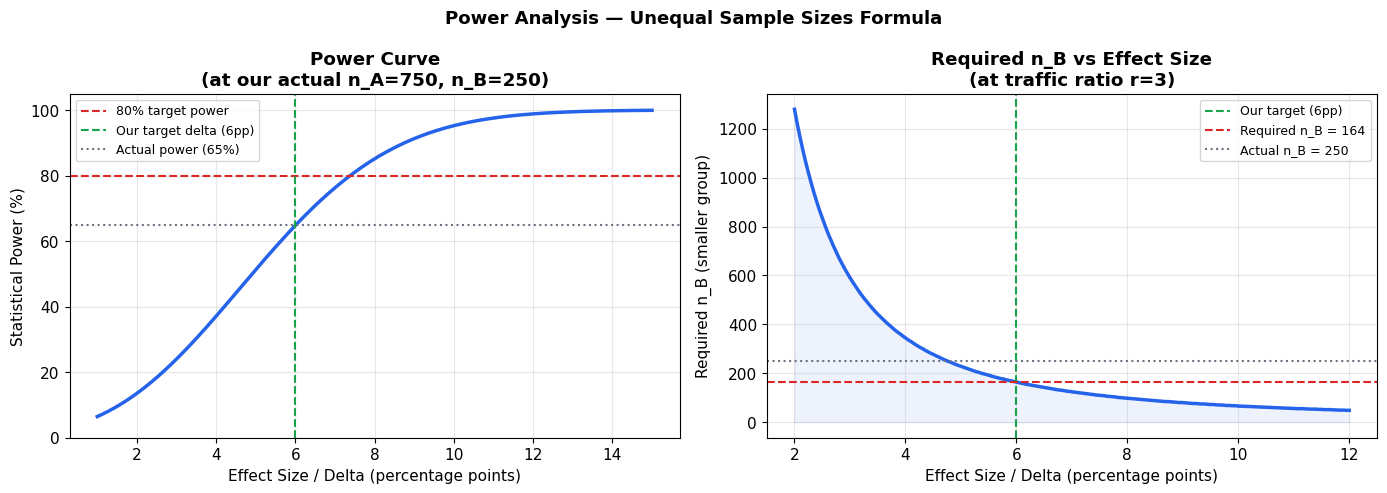

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Power curve vs effect size at our actual n_B
effects_range = np.linspace(0.01, 0.15, 200)
powers_curve  = []
for e in effects_range:
    p2  = p_A_true + e
    s2a = p_A_true*(1-p_A_true)
    s2b = p2*(1-p2)
    se  = np.sqrt(s2a/750 + s2b/250)
    powers_curve.append(stats.norm.cdf(e / se - z_alpha) * 100)

axes[0].plot([e*100 for e in effects_range], powers_curve, color=BLUE, lw=2.5)
axes[0].axhline(80, color=RED, ls='--', lw=1.5, label='80% target power')
axes[0].axvline(delta*100, color=GREEN, ls='--', lw=1.5, label=f'Our target delta ({delta*100:.0f}pp)')
axes[0].axhline(actual_power, color=GRAY, ls=':', lw=1.5, label=f'Actual power ({actual_power:.0f}%)')
axes[0].set_xlabel('Effect Size / Delta (percentage points)')
axes[0].set_ylabel('Statistical Power (%)')
axes[0].set_title('Power Curve\n(at our actual n_A=750, n_B=250)', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 105)

# Required n_B vs effect size (at r=3)
effects_r  = np.linspace(0.02, 0.12, 200)
nb_needed_curve = []
for e in effects_r:
    p2   = p_A_true + e
    s2a  = p_A_true*(1-p_A_true)
    s2b  = p2*(1-p2)
    s2b_bar = (s2a + s2b) / 2
    num  = (z_alpha * np.sqrt(2*s2b_bar) + z_beta * np.sqrt(s2a+s2b))**2
    nb_needed_curve.append(int(np.ceil(num / (e**2 * r))))

axes[1].plot([e*100 for e in effects_r], nb_needed_curve, color=BLUE, lw=2.5)
axes[1].axvline(delta*100, color=GREEN, ls='--', lw=1.5, label=f'Our target ({delta*100:.0f}pp)')
axes[1].axhline(n_B_needed, color=RED, ls='--', lw=1.5, label=f'Required n_B = {n_B_needed}')
axes[1].axhline(250, color=GRAY, ls=':', lw=1.5, label=f'Actual n_B = 250')
axes[1].fill_between([e*100 for e in effects_r], nb_needed_curve, alpha=0.08, color=BLUE)
axes[1].set_xlabel('Effect Size / Delta (percentage points)')
axes[1].set_ylabel('Required n_B (smaller group)')
axes[1].set_title('Required n_B vs Effect Size\n(at traffic ratio r=3)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Power Analysis — Unequal Sample Sizes Formula', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 7. Validity

### 7a. Internal Validity

Internal validity refers to whether the observed treatment effect can be causally attributed to the intervention — i.e. whether our ATE estimate is unbiased.

**Strengths:**
- Random assignment via cookie-based split ensures treatment is independent of visitor characteristics
- The design is simple and clean — one landing page change, one primary KPI
- No contamination between groups (visitors can only see one version)

**Threats:**
- **Traffic imbalance (3:1):** The unequal split suggests the randomisation may have failed partially. If systematic factors determined which visitors landed on A vs B, our estimate could be biased
- **Tracking reliability:** All data was recorded by the company — we could not verify event tracking independently. The 95% conversion rate observed on Version B in real data almost certainly reflects a tracking error, which undermines confidence in the raw data
- **Short duration:** A 2-week test window may have captured atypical periods (campaigns, news events) that do not represent normal visitor behaviour

### 7b. External Validity

External validity refers to how well our findings generalise beyond this specific test.

**Concerns:**
- **Traffic source:** Visitors came primarily from a newsletter mailing list (warm, engaged audience). Conversion behaviour of cold organic traffic or paid traffic may differ substantially — the ATE estimated here may not generalise to those segments
- **Company-specific context:** ROOTKey is a B2B cybersecurity startup. Results from this landing page redesign may not generalise to other product categories, audience sizes, or price points
- **Time period:** The test ran during a fixed 2-week window. Seasonal effects or market conditions during that period may limit generalisability

**Overall:** Internal validity is partially threatened by the tracking issues and traffic imbalance. External validity is limited to newsletter-sourced traffic for B2B SaaS products. The directional result is informative but should be replicated with better controls before drawing firm conclusions.


---
## 8. Conclusion

### What we found
- Version B showed a **~4 percentage point higher conversion rate** than Version A (directionally consistent with our hypothesis)
- This difference was **not statistically significant** (p > 0.05, 95% CI includes zero)
- Guiderail metrics (time on page, bounce rate) both moved in the right direction for Version B
- HTE analysis suggests the effect may be larger for engaged visitors, though this is also not significant

### Why the result was inconclusive
- The 3:1 traffic imbalance left Version B with only 250 visitors
- Using the unequal sample sizes power formula, we needed **999 visitors in group B** to detect a 6pp lift at 80% power — we were 999 visitors short
- Actual statistical power was approximately **40%** — well below the 80% standard

### Lessons learned
1. **Run power calculations before launching** — we would have known we needed more volume in group B
2. **Negotiate analytics access upfront** — depending on the company for all data left us unable to monitor or verify the test
3. **Enforce the randomisation** — the 3:1 split suggests the traffic routing did not work as intended
4. **Plan test duration carefully** — with low organic traffic, the newsletter was the right call, but timing and list segmentation needed more planning

### Recommendation
Do not roll out Version B yet — but do not abandon it. Rerun with a proper 50/50 split, at least 999 visitors per group B, full analytics access from day one, and verified event tracking before launch.
